##### Setup

###### Imports

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.model import earlyStopping

###### Load data

In [ ]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [ ]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

In [ ]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [ ]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

In [ ]:
def latentSpaceRecons2D(n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


##### MNIST

###### Vector Quantized VAE

In [24]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [13]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
data_var = 100.

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim, 
                                 nEmbeddings=n_embeds, beta=beta,
                                 data_var=data_var).to(device)

In [14]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [15]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model.train()
    encoderParams = list(model.encoder.parameters())

    losses = model.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model, batch)

recon grad norm (encoder): 25.6270
vq grad norm (encoder):    0.3493
ratio reconGradNorm/vqGradNorm -> suggested data_var: 73.3629


In [16]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vqvae/',
                checkPointName='vqvae_16_10',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 2.569569 reconLoss: 124.103195 codeLoss: 0.664269 commLoss: 0.664269 vqLoss: 1.328537[ 6400/60000]
totalLoss: 2.787637 reconLoss: 103.084335 codeLoss: 0.878397 commLoss: 0.878397 vqLoss: 1.756793[12800/60000]
totalLoss: 3.092509 reconLoss: 102.298294 codeLoss: 1.034763 commLoss: 1.034763 vqLoss: 2.069526[19200/60000]
totalLoss: 3.048841 reconLoss: 102.767120 codeLoss: 1.010585 commLoss: 1.010585 vqLoss: 2.021170[25600/60000]
totalLoss: 2.864240 reconLoss: 95.906296 codeLoss: 0.952589 commLoss: 0.952589 vqLoss: 1.905177[32000/60000]
totalLoss: 2.798300 reconLoss: 93.441460 codeLoss: 0.931943 commLoss: 0.931943 vqLoss: 1.863885[38400/60000]
totalLoss: 2.629789 reconLoss: 93.365555 codeLoss: 0.848067 commLoss: 0.848067 vqLoss: 1.696133[44800/60000]
totalLoss: 2.643342 reconLoss: 86.618088 codeLoss: 0.888581 commLoss: 0.888581 vqLoss: 1.777161[51200/60000]
totalLoss: 2.910439 reconLoss: 96.181419 codeLoss: 0.974313 commLoss: 0.974313 vqLos

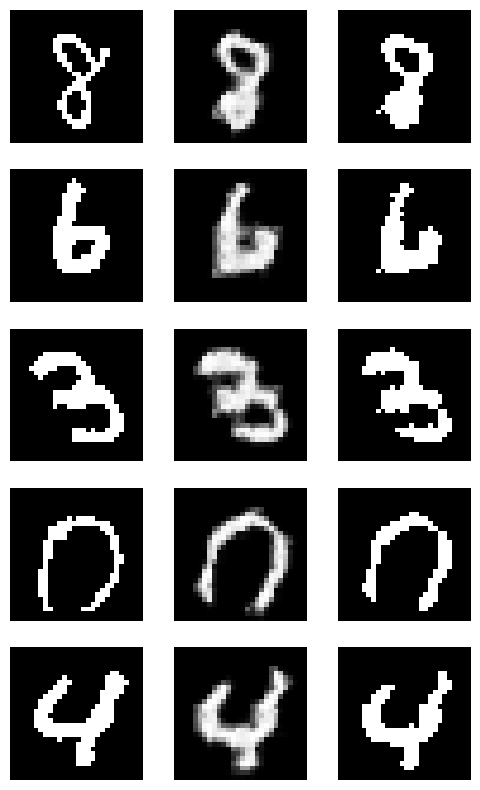

In [21]:
nCols = 3
nRows = 5

figure = plt.figure(figsize=(6, 10))
model.eval()

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

###### Autoencoding VAE

In [78]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)
model.load_state_dict(torch.load('../checkpoints/mnist_vae/vae_2-13.model', weights_only=True)['model_state_dict'])

<All keys matched successfully>

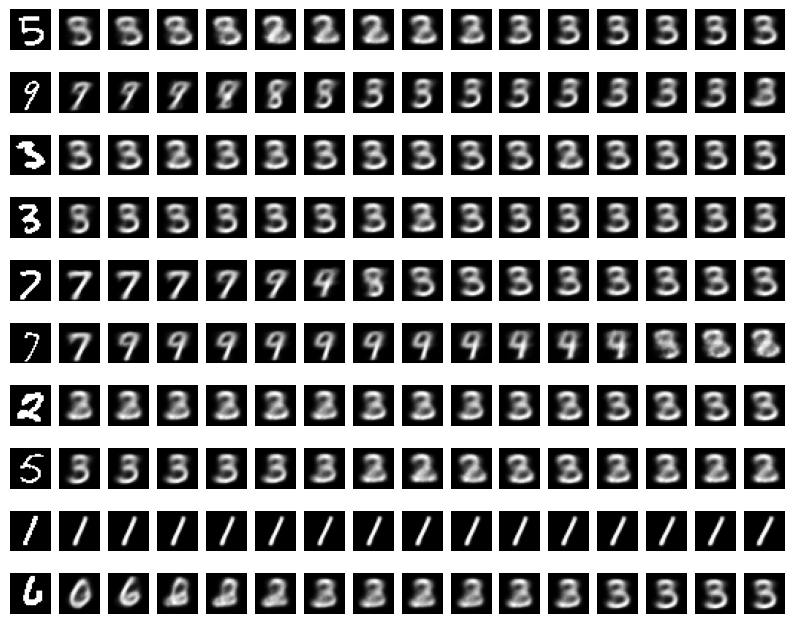

In [79]:
nCols = 16
nRows = 10

model.eval()

figure = plt.figure(figsize=(10, 8))
idxs = []
with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        idxs.append(sidx)
        img = trainImageData[sidx].unsqueeze(0).to(device)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model.forward(img)[0]
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

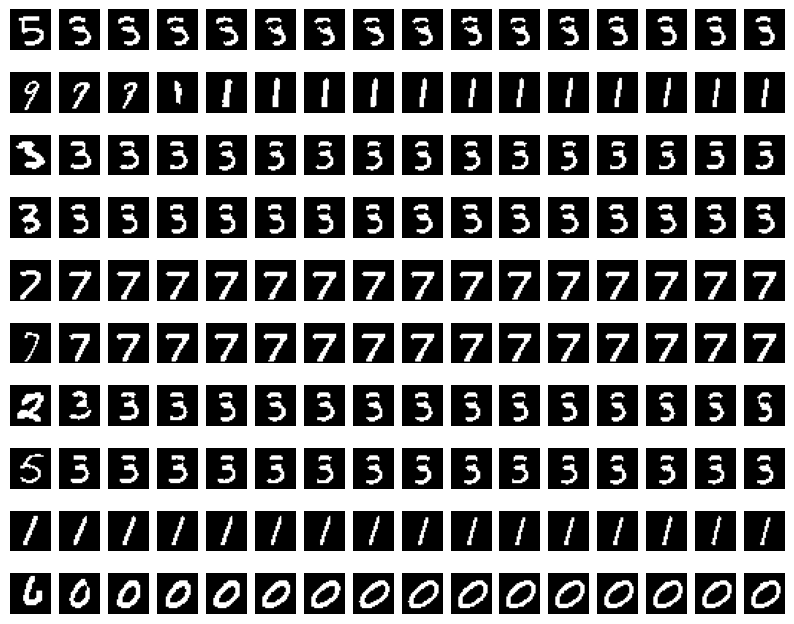

In [80]:
figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        img = torch.where(img > 0.5, 1.0, 0.0)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model.forward(img)[0]
            img = torch.where(img > 0.5, 1.0, 0.0)
            
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

In [93]:
# build the encoder and decoder networks
hid_dim = 4

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.995).to(device)

In [94]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.1, mode='min', restoreBestWeights=True)

In [95]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_avae/',
                checkPointName='avae_98',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 208.786346 reconLoss: 203.801361 klLoss: 3.254974 condLoss: 1.730007[12800/60000]
totalLoss: 182.850937 reconLoss: 178.506119 klLoss: 2.947720 condLoss: 1.397092[25600/60000]
totalLoss: 163.967194 reconLoss: 160.002182 klLoss: 3.049180 condLoss: 0.915837[38400/60000]
totalLoss: 142.542267 reconLoss: 138.604645 klLoss: 3.227386 condLoss: 0.710231[51200/60000]
Validation Error: 139.025990
Epoch 2
-------------------------------
totalLoss: 132.618225 reconLoss: 128.835220 klLoss: 3.342320 condLoss: 0.440688[12800/60000]
totalLoss: 133.743240 reconLoss: 129.922012 klLoss: 3.302738 condLoss: 0.518491[25600/60000]
totalLoss: 129.471802 reconLoss: 125.628601 klLoss: 3.425328 condLoss: 0.417881[38400/60000]
totalLoss: 128.355164 reconLoss: 124.449234 klLoss: 3.374182 condLoss: 0.531751[51200/60000]
Validation Error: 129.790523
Epoch 3
-------------------------------
totalLoss: 126.943909 reconLoss: 123.205048 klLoss: 3.373480 condLoss: 0.36538

In [96]:
if hid_dim==2:
    latentSpaceRecons2D(scale=2.0, n=30)

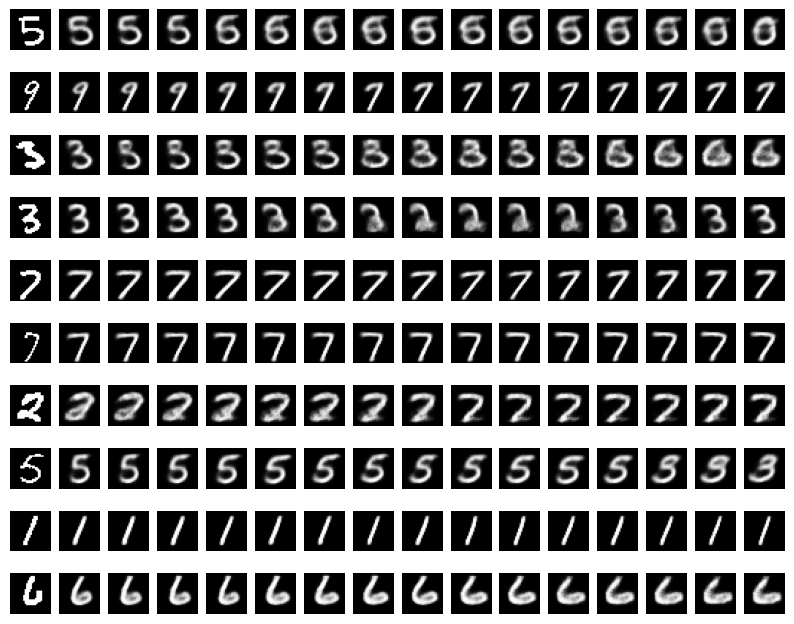

In [97]:
model.eval()

figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model.forward(img)[0]
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

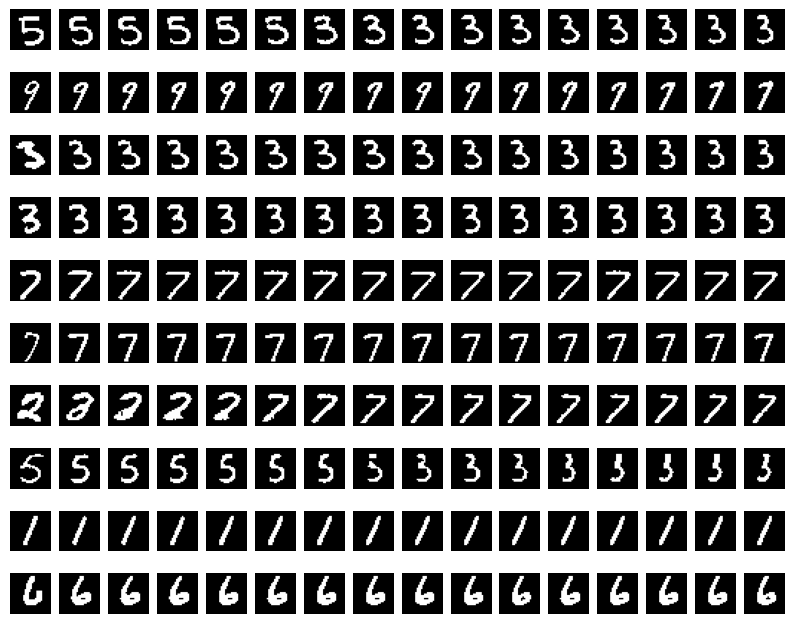

In [98]:
figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        img = torch.where(img > 0.5, 1.0, 0.0)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model.forward(img)[0]
            img = torch.where(img > 0.5, 1.0, 0.0)
            
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()